# 📊 Régression Logistique - Modèle de base

## 📋 Objectif

Ce notebook implémente un modèle **basique** de régression logistique pour servir de **baseline** de comparaison.

**Approche volontairement simple :**
- Pas de feature engineering
- Encodage simple (LabelEncoder)
- Paramètres par défaut

---

## 📦 Import des bibliothèques

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    f1_score, 
    accuracy_score,
    roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

---

## 📊 1. Chargement des données

In [2]:
train_df = pd.read_csv('conversion_data_train.csv')
test_df = pd.read_csv('conversion_data_test.csv')

print(f"📊 Données d'entraînement : {train_df.shape[0]:,} lignes, {train_df.shape[1]} colonnes")
print(f"📊 Données de test : {test_df.shape[0]:,} lignes")

📊 Données d'entraînement : 284,580 lignes, 6 colonnes
📊 Données de test : 31,620 lignes


In [3]:
train_df.head()

,country,age,new_user,source,total_pages_visited,converted
0,China,22,1,Direct,2,0
1,UK,21,1,Ads,3,0
2,Germany,20,0,Seo,14,1
3,US,23,1,Seo,3,0
4,US,28,1,Direct,3,0


In [4]:
print(f"🎯 Taux de conversion : {train_df['converted'].mean() * 100:.2f}%")

🎯 Taux de conversion : 3.23%


---

## 🔧 2. Préparation des données (SIMPLE)

Encodage basique avec LabelEncoder uniquement.

In [5]:
# Copie des dataframes
train_encoded = train_df.copy()
test_encoded = test_df.copy()

# Encodage simple des variables catégorielles
label_encoders = {}
categorical_cols = ['country', 'source']

for col in categorical_cols:
    le = LabelEncoder()
    train_encoded[col] = le.fit_transform(train_encoded[col])
    test_encoded[col] = le.transform(test_encoded[col])
    label_encoders[col] = le
    print(f"✓ '{col}' encodé : {dict(zip(le.classes_, range(len(le.classes_))))}")

✓ 'country' encodé : {'China': 0, 'Germany': 1, 'UK': 2, 'US': 3}
✓ 'source' encodé : {'Ads': 0, 'Direct': 1, 'Seo': 2}


In [6]:
# Sélection des features (SANS feature engineering)
feature_cols = ['country', 'age', 'new_user', 'source', 'total_pages_visited']

X = train_encoded[feature_cols]
y = train_encoded['converted']
X_test = test_encoded[feature_cols]

print(f"\nFeatures utilisées : {feature_cols}")


Features utilisées : ['country', 'age', 'new_user', 'source', 'total_pages_visited']


In [7]:
# Division train/validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"📊 Ensemble d'entraînement : {X_train.shape[0]:,} échantillons")
print(f"📊 Ensemble de validation : {X_val.shape[0]:,} échantillons")

📊 Ensemble d'entraînement : 227,664 échantillons
📊 Ensemble de validation : 56,916 échantillons


---

## 🎯 3. Entraînement de la Régression Logistique

Modèle avec paramètres par défaut.

In [8]:
# Modèle de régression logistique BASIQUE
model = LogisticRegression(
    random_state=42,
    max_iter=1000  # Augmenter pour garantir la convergence
)

print("🎯 Entraînement de la Régression Logistique...")
model.fit(X_train, y_train)
print("✅ Modèle entraîné avec succès!")

🎯 Entraînement de la Régression Logistique...
✅ Modèle entraîné avec succès!


---

## 📊 4. Évaluation du modèle

In [9]:
# Prédictions
y_pred = model.predict(X_val)
y_pred_proba = model.predict_proba(X_val)[:, 1]

# Métriques
accuracy = accuracy_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
roc_auc = roc_auc_score(y_val, y_pred_proba)

print("📊 MÉTRIQUES DE PERFORMANCE (RÉGRESSION LOGISTIQUE BASIQUE)")
print("=" * 60)
print(f"  Accuracy  : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  F1-Score  : {f1:.4f}")
print(f"  ROC-AUC   : {roc_auc:.4f}")

📊 MÉTRIQUES DE PERFORMANCE (RÉGRESSION LOGISTIQUE BASIQUE)
  Accuracy  : 0.9859 (98.59%)
  F1-Score  : 0.7546
  ROC-AUC   : 0.9846


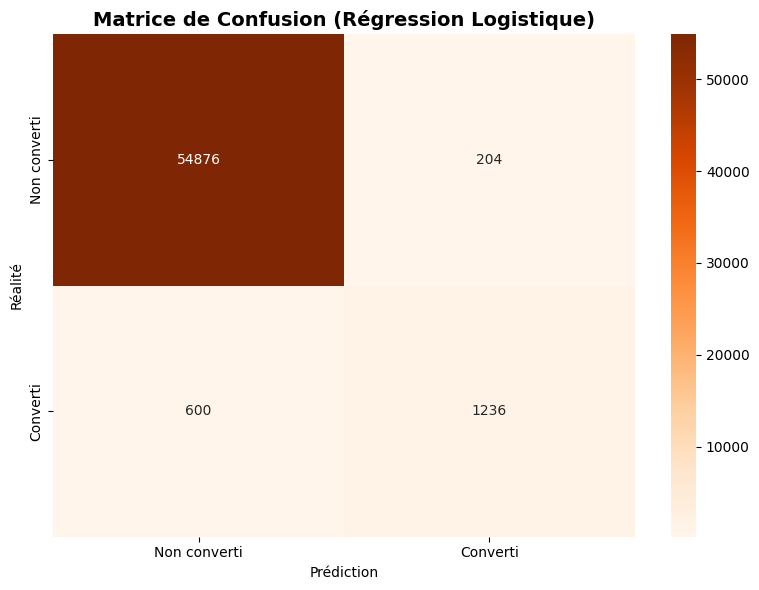


📋 Détail :
  TN : 54,876 | FP : 204
  FN : 600 | TP : 1,236


In [10]:
# Matrice de confusion
cm = confusion_matrix(y_val, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax,
            xticklabels=['Non converti', 'Converti'],
            yticklabels=['Non converti', 'Converti'])
ax.set_title('Matrice de Confusion (Régression Logistique)', fontsize=14, fontweight='bold')
ax.set_xlabel('Prédiction')
ax.set_ylabel('Réalité')
plt.tight_layout()
plt.show()

print(f"\n📋 Détail :")
print(f"  TN : {cm[0,0]:,} | FP : {cm[0,1]:,}")
print(f"  FN : {cm[1,0]:,} | TP : {cm[1,1]:,}")

In [11]:
print("📋 RAPPORT DE CLASSIFICATION")
print("=" * 60)
print(classification_report(y_val, y_pred, target_names=['Non converti (0)', 'Converti (1)']))

📋 RAPPORT DE CLASSIFICATION
                  precision    recall  f1-score   support

Non converti (0)       0.99      1.00      0.99     55080
    Converti (1)       0.86      0.67      0.75      1836

        accuracy                           0.99     56916
       macro avg       0.92      0.83      0.87     56916
    weighted avg       0.98      0.99      0.99     56916



---

## 🔍 5. Coefficients du modèle

In [12]:
# Coefficients de la régression logistique
coefficients = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print("🔍 COEFFICIENTS DE LA RÉGRESSION LOGISTIQUE")
print("=" * 50)
for _, row in coefficients.iterrows():
    sign = "+" if row['coefficient'] > 0 else ""
    print(f"  {row['feature']:25} : {sign}{row['coefficient']:.4f}")

print(f"\n  Intercept : {model.intercept_[0]:.4f}")

🔍 COEFFICIENTS DE LA RÉGRESSION LOGISTIQUE
  new_user                  : -1.6960
  total_pages_visited       : +0.7574
  country                   : +0.4900
  age                       : -0.0732
  source                    : -0.0021

  Intercept : -8.4751


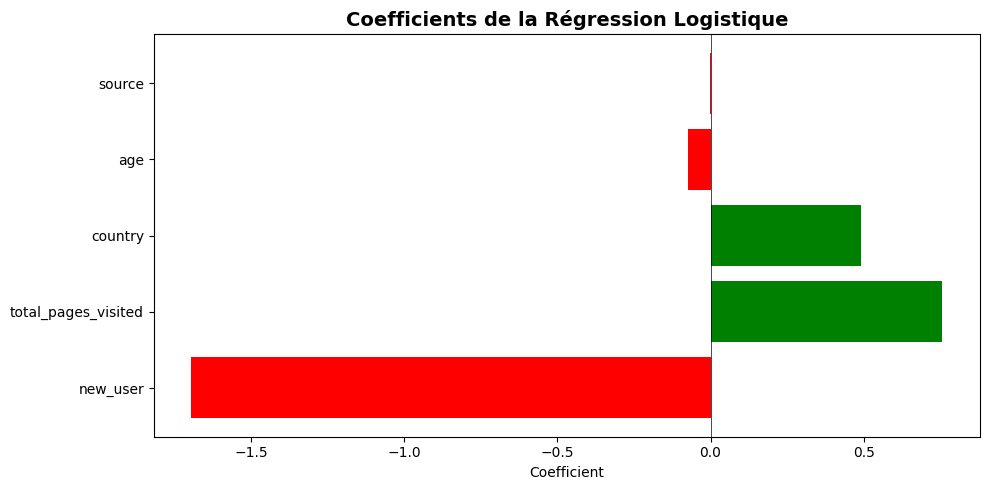

In [13]:
# Visualisation des coefficients
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['green' if c > 0 else 'red' for c in coefficients['coefficient']]
ax.barh(coefficients['feature'], coefficients['coefficient'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('Coefficient')
ax.set_title('Coefficients de la Régression Logistique', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Interprétation des coefficients

- **Coefficient positif** : augmente la probabilité de conversion
- **Coefficient négatif** : diminue la probabilité de conversion
- La **magnitude** indique l'importance relative

---

## 🎲 6. Prédictions sur les données de test

In [14]:
# Ré-entraînement sur tout le dataset
model.fit(X, y)

# Prédictions
test_predictions = model.predict(X_test)

print("🎲 PRÉDICTIONS SUR LES DONNÉES DE TEST")
print("=" * 50)
print(f"  Prédictions de conversion : {test_predictions.sum():,}")
print(f"  Taux de conversion prédit : {test_predictions.mean()*100:.2f}%")

# Sauvegarde
submission = pd.DataFrame({'converted': test_predictions})
submission.to_csv('predictions_logistic_basique.csv', index=False)
print("\n✅ Prédictions sauvegardées dans 'predictions_logistic_basique.csv'")

🎲 PRÉDICTIONS SUR LES DONNÉES DE TEST
  Prédictions de conversion : 806
  Taux de conversion prédit : 2.55%

✅ Prédictions sauvegardées dans 'predictions_logistic_basique.csv'


---

## 📝 7. Comparaison avec Gradient Boosting

| Métrique | Régression Logistique | Gradient Boosting |
|----------|----------------------|-------------------|
| Accuracy | À observer | ~98.6% |
| F1-Score | À observer | ~0.76 |
| ROC-AUC | À observer | ~0.99 |

### Avantages de la Régression Logistique
- ✅ Simple et rapide
- ✅ Coefficients interprétables
- ✅ Moins de risque d'overfitting

### Inconvénients
- ❌ Hypothèse de linéarité
- ❌ Ne capture pas les interactions complexes
- ❌ Performances généralement inférieures sur des données non-linéaires

---

*Modèle baseline - 15 décembre 2025*